# 이상지질혈증 예측 - XGBoost v3 Threshold 탐색

- 타겟: `이상지질혈증유병` (0: 없음 / 1: 있음)
- 데이터: `hn_all_preprocessed_v2.1.csv`
- 모델: XGBoost (v3 Optuna 최적 파라미터 고정)
- 목표: **Recall ≥ 0.80 조건 하 F1 최대화**
- 검증: Stratified 5-Fold CV

In [14]:
import os
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

matplotlib.rcParams["font.family"] = "DejaVu Sans"
warnings.filterwarnings("ignore")

CURRENT_DIR = os.path.dirname(os.path.abspath(""))
BASE_DIR = os.path.join(CURRENT_DIR, "..")
DATA_PATH = os.path.join(BASE_DIR, "data", "hn_all_preprocessed_v2.1.csv")
FEATURES_DIR = os.path.join(BASE_DIR, "features")
NPY_DIR = os.path.join(BASE_DIR, "outputs", "oof")
sys.path.insert(0, FEATURES_DIR)

RANDOM_STATE = 42

## 1. 데이터 로드

In [15]:
df = pd.read_csv(DATA_PATH)
print(f"로드 완료 | shape: {df.shape}")

로드 완료 | shape: (19765, 31)


## 2. ✏️ Feature Engineering (필요 시 해제)

In [16]:
# df = add_age_bin(df)
# df = add_family_sum(df, hypertension=True, diabetes=True, dyslipidemia=True)
# df = add_bmi_bin(df)
# df = add_alcohol_load(df)
# df = add_exercise_total(df)
# df = add_body_features(df)
# df = add_age_family_interaction(df, hypertension=False, diabetes=False)

print(f"피처 엔지니어링 완료 | shape: {df.shape}")

피처 엔지니어링 완료 | shape: (19765, 31)


## 3. 피처 / 타겟 분리

In [17]:
TARGET = "이상지질혈증유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)
neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos
print(f"샘플 수: {len(y)}  |  정상: {neg}  |  이상지질혈증: {pos}")
print(f"불균형 비율: {ratio:.4f}:1  |  피처 수: {X.shape[1]}")

샘플 수: 19175  |  정상: 13732  |  이상지질혈증: 5443
불균형 비율: 2.5229:1  |  피처 수: 28


## 4. v3 Optuna 최적 파라미터 설정

In [18]:
best_params = {
    "n_estimators": 487,
    "learning_rate": 0.08927180304353628,
    "max_depth": 7,
    "min_child_weight": 6,
    "subsample": 0.6624074561769746,
    "colsample_bytree": 0.662397808134481,
    "gamma": 0.05808361216819946,
    "reg_alpha": 0.8661761457749352,
    "reg_lambda": 2.002787529358022,
    "scale_pos_weight": ratio,
    "eval_metric": "auc",
    "early_stopping_rounds": 50,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0,
}
print("파라미터 설정 완료")

파라미터 설정 완료


## 5. Stratified 5-Fold CV — OOF proba 수집

In [19]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
fold_scores = []

print("=" * 65)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model = xgb.XGBClassifier(**best_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba
    pred = (proba >= 0.45).astype(int)
    cm_f = confusion_matrix(y_val, pred)
    fold_scores.append(
        {
            "fold": fold,
            "auc": roc_auc_score(y_val, proba),
            "f1": f1_score(y_val, pred),
            "recall": recall_score(y_val, pred),
            "precision": precision_score(y_val, pred),
            "fp": int(cm_f[0, 1]),
            "best_iter": model.best_iteration,
        }
    )
    print(
        f"  Fold {fold} | AUC: {fold_scores[-1]['auc']:.4f} | "
        f"Recall: {fold_scores[-1]['recall']:.4f} | "
        f"F1: {fold_scores[-1]['f1']:.4f}"
    )

scores_df = pd.DataFrame(fold_scores)
print("=" * 65)
print(
    f"  평균 | AUC: {scores_df.auc.mean():.4f} | Recall: {scores_df.recall.mean():.4f} | F1: {scores_df.f1.mean():.4f}"
)

  Fold 1 | AUC: 0.7793 | Recall: 0.8548 | F1: 0.5782
  Fold 2 | AUC: 0.8005 | Recall: 0.8686 | F1: 0.6027
  Fold 3 | AUC: 0.7853 | Recall: 0.8384 | F1: 0.5786
  Fold 4 | AUC: 0.7933 | Recall: 0.8356 | F1: 0.5890
  Fold 5 | AUC: 0.7866 | Recall: 0.8567 | F1: 0.5857
  평균 | AUC: 0.7890 | Recall: 0.8508 | F1: 0.5868


## 6. OOF proba 저장 (.npy)

In [20]:
os.makedirs(NPY_DIR, exist_ok=True)
npy_path = os.path.join(NPY_DIR, "oof_proba_HL_xgboost_v3_threshold.npy")
oof_array = np.stack([oof_proba, y.values], axis=1)
np.save(npy_path, oof_array)
print(f"저장 완료 → {npy_path}")
loaded = np.load(npy_path)
print(f"로드 확인: shape={loaded.shape}, 일치={np.allclose(oof_array, loaded)}")

저장 완료 → /Users/Jiyeon/Desktop/final_project/ML/model/../outputs/oof/oof_proba_HL_xgboost_v3_threshold.npy
로드 확인: shape=(19175, 2), 일치=True


## 7. Threshold 탐색 (0.30 ~ 0.65)

In [21]:
thresholds = np.arange(0.30, 0.66, 0.05).round(2)
thr_results = []

print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>8} {'FP':>6} {'FN':>6}")
print("-" * 55)
for t in thresholds:
    pred_t = (oof_proba >= t).astype(int)
    cm_t = confusion_matrix(y, pred_t)
    rec = recall_score(y, pred_t)
    prec = precision_score(y, pred_t)
    f1 = f1_score(y, pred_t)
    thr_results.append(
        {"threshold": t, "recall": rec, "precision": prec, "f1": f1, "fp": int(cm_t[0, 1]), "fn": int(cm_t[1, 0])}
    )
    marker = "  ◀ current" if t == 0.45 else ""
    print(f"{t:>10.2f} {rec:>8.4f} {prec:>10.4f} {f1:>8.4f} {cm_t[0, 1]:>6} {cm_t[1, 0]:>6}{marker}")

thr_df = pd.DataFrame(thr_results)
cond = thr_df[thr_df.recall >= 0.80]
best_row = cond.loc[cond.f1.idxmax()] if len(cond) > 0 else thr_df.loc[thr_df.f1.idxmax()]
BEST_THRESHOLD = best_row.threshold
print(
    f"\n★ Recall≥0.80 최적: threshold={BEST_THRESHOLD:.2f} | "
    f"Recall={best_row.recall:.4f} | F1={best_row.f1:.4f} | "
    f"FP={int(best_row.fp)} | FN={int(best_row.fn)}"
)

 Threshold   Recall  Precision       F1     FP     FN
-------------------------------------------------------
      0.30   0.9427     0.4042   0.5658   7563    312
      0.35   0.9192     0.4145   0.5713   7067    440
      0.40   0.8892     0.4294   0.5792   6431    603
      0.45   0.8508     0.4478   0.5868   5711    812  ◀ current
      0.50   0.7931     0.4661   0.5871   4945   1126
      0.55   0.7082     0.4896   0.5790   4019   1588
      0.60   0.6105     0.5170   0.5599   3104   2120
      0.65   0.4927     0.5478   0.5188   2214   2761

★ Recall≥0.80 최적: threshold=0.45 | Recall=0.8508 | F1=0.5868 | FP=5711 | FN=812


## 8. Threshold별 지표 시각화

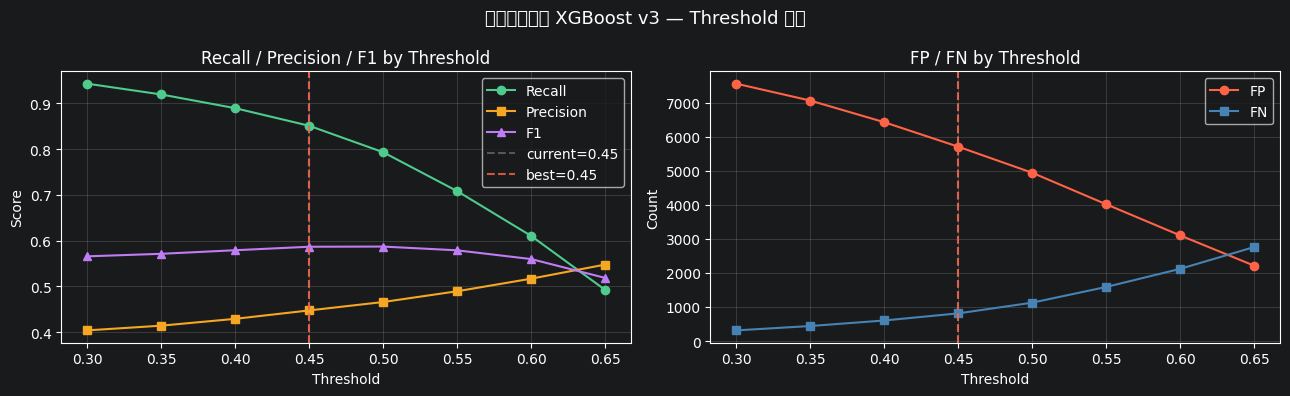

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(thr_df.threshold, thr_df.recall, marker="o", label="Recall", color="#4ecb8d")
axes[0].plot(thr_df.threshold, thr_df.precision, marker="s", label="Precision", color="#f5a623")
axes[0].plot(thr_df.threshold, thr_df.f1, marker="^", label="F1", color="#bf7cf5")
axes[0].axvline(0.45, color="gray", linestyle="--", alpha=0.6, label="current=0.45")
axes[0].axvline(BEST_THRESHOLD, color="tomato", linestyle="--", alpha=0.8, label=f"best={BEST_THRESHOLD:.2f}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Recall / Precision / F1 by Threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(thr_df.threshold, thr_df.fp, marker="o", color="tomato", label="FP")
axes[1].plot(thr_df.threshold, thr_df.fn, marker="s", color="steelblue", label="FN")
axes[1].axvline(0.45, color="gray", linestyle="--", alpha=0.6)
axes[1].axvline(BEST_THRESHOLD, color="tomato", linestyle="--", alpha=0.8)
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Count")
axes[1].set_title("FP / FN by Threshold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("이상지질혈증 XGBoost v3 — Threshold 분석", fontsize=13)
plt.tight_layout()
plt.show()

## 9. 최적 Threshold 확정 & 현재 비교

In [23]:
pred_cur = (oof_proba >= 0.45).astype(int)
pred_best = (oof_proba >= BEST_THRESHOLD).astype(int)
cm_cur = confusion_matrix(y, pred_cur)
cm_best = confusion_matrix(y, pred_best)

print("=" * 55)
print(f"  {'지표':<12}  {'current (0.45)':>14}  {f'best ({BEST_THRESHOLD:.2f})':>10}  변화")
print("=" * 55)
for name, fn in [("Recall", recall_score), ("Precision", precision_score), ("F1-score", f1_score), ("AUC-ROC", None)]:
    if fn:
        v_cur, v_best = fn(y, pred_cur), fn(y, pred_best)
    else:
        v_cur = v_best = roc_auc_score(y, oof_proba)
    d = v_best - v_cur
    arrow = "▲" if d > 0 else ("▼" if d < 0 else "─")
    print(f"  {name:<12}  {v_cur:>14.4f}  {v_best:>10.4f}  {arrow} {abs(d):.4f}")
print(
    f"  {'FP':<12}  {cm_cur[0, 1]:>14}  {cm_best[0, 1]:>10}  "
    f"{'▼' if cm_best[0, 1] < cm_cur[0, 1] else '▲'} {abs(cm_best[0, 1] - cm_cur[0, 1])}"
)
print(
    f"  {'FN':<12}  {cm_cur[1, 0]:>14}  {cm_best[1, 0]:>10}  "
    f"{'▼' if cm_best[1, 0] < cm_cur[1, 0] else '▲'} {abs(cm_best[1, 0] - cm_cur[1, 0])}"
)
print("=" * 55)
print(f"\n[분류 리포트 — threshold {BEST_THRESHOLD:.2f}]")
print(classification_report(y, pred_best, target_names=["정상(0)", "이상지질혈증(1)"]))

  지표            current (0.45)  best (0.45)  변화
  Recall                0.8508      0.8508  ─ 0.0000
  Precision             0.4478      0.4478  ─ 0.0000
  F1-score              0.5868      0.5868  ─ 0.0000
  AUC-ROC               0.7888      0.7888  ─ 0.0000
  FP                      5711        5711  ▲ 0
  FN                       812         812  ▲ 0

[분류 리포트 — threshold 0.45]
              precision    recall  f1-score   support

       정상(0)       0.91      0.58      0.71     13732
   이상지질혈증(1)       0.45      0.85      0.59      5443

    accuracy                           0.66     19175
   macro avg       0.68      0.72      0.65     19175
weighted avg       0.78      0.66      0.68     19175



## 10. Confusion Matrix 비교

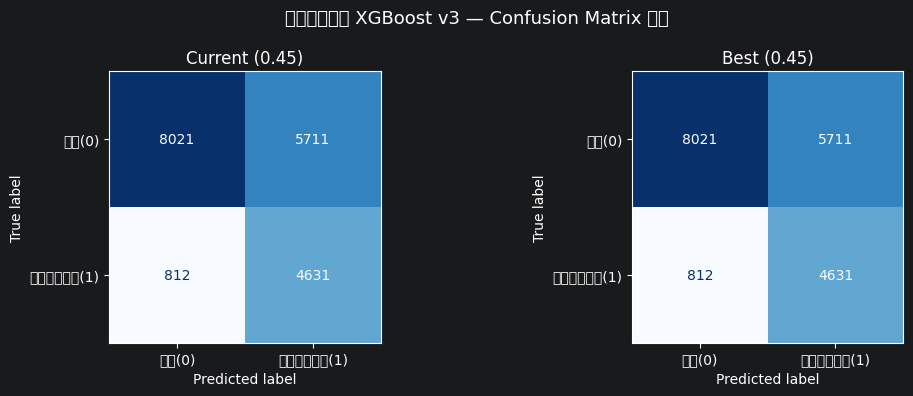

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title in zip(axes, [cm_cur, cm_best], ["Current (0.45)", f"Best ({BEST_THRESHOLD:.2f})"]):
    ConfusionMatrixDisplay(cm, display_labels=["정상(0)", "이상지질혈증(1)"]).plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title)
plt.suptitle("이상지질혈증 XGBoost v3 — Confusion Matrix 비교", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Precision-Recall 커브

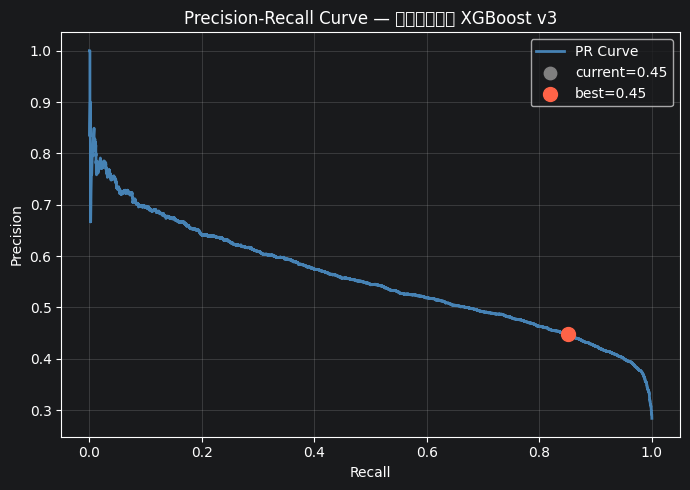

In [25]:
prec_curve, rec_curve, thr_curve = precision_recall_curve(y, oof_proba)
plt.figure(figsize=(7, 5))
plt.plot(rec_curve, prec_curve, color="steelblue", lw=2, label="PR Curve")
idx_cur = np.argmin(np.abs(thr_curve - 0.45))
idx_best = np.argmin(np.abs(thr_curve - BEST_THRESHOLD))
plt.scatter(rec_curve[idx_cur], prec_curve[idx_cur], s=80, color="gray", zorder=5, label="current=0.45")
plt.scatter(
    rec_curve[idx_best], prec_curve[idx_best], s=100, color="tomato", zorder=5, label=f"best={BEST_THRESHOLD:.2f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — 이상지질혈증 XGBoost v3")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. DB 로그 저장

In [26]:
sys.path.insert(0, BASE_DIR)
from model_logger import ModelLogger

logger = ModelLogger(os.path.join(BASE_DIR, "model_result.db"))
pred_final = (oof_proba >= BEST_THRESHOLD).astype(int)
cm_final = confusion_matrix(y, pred_final)

base_cols = pd.read_csv(DATA_PATH).columns.tolist()
fe_cols = [c for c in X.columns if c not in base_cols]
fe_note = f"FE: {fe_cols}" if fe_cols else "FE 없음"

run_id = logger.log_run(
    target_var="이상지질혈증",
    model_name="XGBoost",
    stage=f"v3_threshold_{BEST_THRESHOLD:.2f}",
    hyperparams={
        "learning_rate": best_params["learning_rate"],
        "max_depth": best_params["max_depth"],
        "n_estimators": best_params["n_estimators"],
        "class_weight": {0: 1.0, 1: round(ratio, 4)},
        "min_child_weight": best_params["min_child_weight"],
        "subsample": best_params["subsample"],
        "colsample_bytree": best_params["colsample_bytree"],
        "gamma": best_params["gamma"],
        "reg_alpha": best_params["reg_alpha"],
        "reg_lambda": best_params["reg_lambda"],
    },
    data_info={"feature_count": X.shape[1], "train_test_split": "5-Fold CV", "scaling_method": "None"},
    oof_metrics={
        "accuracy": float((pred_final == y).mean()),
        "recall": recall_score(y, pred_final),
        "precision": precision_score(y, pred_final),
        "f1_score": f1_score(y, pred_final),
        "auc_roc": roc_auc_score(y, oof_proba),
        "cm": cm_final.tolist(),
    },
    fold_scores=scores_df.to_dict("records"),
    threshold_results=thr_df.to_dict("records"),
    top_features={},
    note=f"v3 threshold 탐색. {fe_note}",
)
print(f"저장 완료 → run_id: {run_id}")
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=48 | 이상지질혈증 XGBoost (v3_threshold_0.45)
저장 완료 → run_id: 48
 run_id          created_at target_var model_name             stage  auc_roc   recall  precision  f1_score  accuracy
     48 2026-05-19 13:49:54     이상지질혈증    XGBoost v3_threshold_0.45 0.788788 0.850818   0.447786  0.586760  0.659817
     47 2026-05-19 13:15:04        고혈압   CatBoost v3_threshold_0.50 0.856580 0.839892   0.580681  0.686637  0.753104
     46 2026-05-19 13:15:00         당뇨   CatBoost v3_threshold_0.50 0.809118 0.819626   0.419266  0.554756  0.689284
     45 2026-05-19 13:13:29         당뇨   CatBoost v3_threshold_0.50 0.831560 0.800945   0.451957  0.577847  0.723617
     44 2026-05-19 13:13:25        고혈압   CatBoost v3_threshold_0.50 0.856580 0.839892   0.580681  0.686637  0.753104
     43 2026-05-19 13:13:23     이상지질혈증    XGBoost v3_threshold_0.45 0.788788 0.850818   0.447786  0.586760  0.659817
     42 2026-05-19 11:58:20        고혈압   CatBoost         v3_optuna 0.856580 0.839892   0.580